In [ ]:
!pip install librosa scikit-learn numpy matplotlib seaborn joblib tqdm -q

import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from pathlib import Path
from collections import Counter

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print("Files in MyDrive:")
for f in os.listdir('/content/drive/MyDrive'):
    print(f)

Files in MyDrive:
keystroke_clean.zip
Colab Notebooks
svm_keystroke_model.pkl


In [ ]:
ZIP_PATH = '/content/drive/MyDrive/keystroke_clean.zip'
EXTRACT_DIR = '/content/dataset'

# remove old extraction
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting zip file...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Done!")

Extracting zip file...
Done!


In [ ]:
print("Top-level contents inside extracted dataset:")
for item in os.listdir(EXTRACT_DIR):
    print("-", item)

Top-level contents inside extracted dataset:
- keystroke_clean


In [ ]:
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')

    if level <= 2:
        for f in files[:5]:
            print(f'{indent}  {f}')
        if len(files) > 5:
            print(f'{indent}  ... ({len(files)} files total)')

    if level > 3:
        dirs[:] = []

dataset/
  keystroke_clean/
    Untitled.ipynb
    .ipynb_checkpoints/
      Untitled-checkpoint.ipynb
    features/
    src/
    data_work/
    data_raw/
      Valid-20260305T062515Z-3-001.zip
      Test-20260305T062512Z-3-001.zip
      Train-20260305T062514Z-3-001.zip
      ALL_DATA-20260305T062510Z-3-001.zip
      ALL_DATA/
        ALL_DATA/
      Train/
        Train/
      Test/
        Test/
      Valid/
        Valid/
    models/
    .venv/
      .gitignore
      pyvenv.cfg
      etc/
        jupyter/
      Include/
      Lib/
        site-packages/
      share/
        icons/
        jupyter/
        applications/
        man/
      Scripts/
    results/


In [ ]:
DATA_ROOT = '/content/dataset/keystroke_clean/data_raw'

for split in ['Train', 'Test', 'Valid']:
    split_path = os.path.join(DATA_ROOT, split, split)
    print(f"\n===== {split_path} =====")

    if not os.path.exists(split_path):
        print("Path does not exist")
        continue

    items = os.listdir(split_path)
    print("First 20 items:")
    for item in items[:20]:
        print("-", item)


===== /content/dataset/keystroke_clean/data_raw/Train/Train =====
First 20 items:
- audio_data
- labels.csv

===== /content/dataset/keystroke_clean/data_raw/Test/Test =====
First 20 items:
- audio_data
- labels.csv

===== /content/dataset/keystroke_clean/data_raw/Valid/Valid =====
First 20 items:
- audio_data
- labels.csv


In [ ]:
for split in ['Train', 'Test', 'Valid']:
    split_path = os.path.join(DATA_ROOT, split, split)
    print(f"\n===== Inspecting {split} =====")

    if not os.path.exists(split_path):
        print("Path does not exist")
        continue

    subfolders = [x for x in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, x))]
    files = [x for x in os.listdir(split_path) if os.path.isfile(os.path.join(split_path, x))]

    print("Subfolders:", subfolders[:20])
    print("Files:", files[:20])

    if subfolders:
        first_sub = os.path.join(split_path, subfolders[0])
        print(f"\nInside first subfolder: {first_sub}")
        inner_items = os.listdir(first_sub)
        for x in inner_items[:20]:
            print("  -", x)


===== Inspecting Train =====
Subfolders: ['audio_data']
Files: ['labels.csv']

Inside first subfolder: /content/dataset/keystroke_clean/data_raw/Train/Train/audio_data
  - q_245.wav
  - v_999.wav
  - m_474.wav
  - x_86.wav
  - f_376.wav
  - m_860.wav
  - g_127.wav
  - z_531.wav
  - space_666.wav
  - c_497.wav
  - q_598.wav
  - x_334.wav
  - z_857.wav
  - g_575.wav
  - u_78.wav
  - s_437.wav
  - f_503.wav
  - m_681.wav
  - g_699.wav
  - w_266.wav

===== Inspecting Test =====
Subfolders: ['audio_data']
Files: ['labels.csv']

Inside first subfolder: /content/dataset/keystroke_clean/data_raw/Test/Test/audio_data
  - x_572.wav
  - s_210.wav
  - u_962.wav
  - m_94.wav
  - j_297.wav
  - m_540.wav
  - o_452.wav
  - i_889.wav
  - x_657.wav
  - space_127.wav
  - b_778.wav
  - e_542.wav
  - h_938.wav
  - o_210.wav
  - g_995.wav
  - i_118.wav
  - u_932.wav
  - k_772.wav
  - space_982.wav
  - g_815.wav

===== Inspecting Valid =====
Subfolders: ['audio_data']
Files: ['labels.csv']

Inside first sub

In [ ]:
import pandas as pd
from pathlib import Path

TRAIN_DIR = Path('/content/dataset/keystroke_clean/data_raw/Train/Train')
VALID_DIR = Path('/content/dataset/keystroke_clean/data_raw/Valid/Valid')
TEST_DIR  = Path('/content/dataset/keystroke_clean/data_raw/Test/Test')

def inspect_csv(split_dir, split_name):
    csv_path = split_dir / 'labels.csv'
    audio_dir = split_dir / 'audio_data'

    print(f"\n===== {split_name} =====")
    print("CSV exists   :", csv_path.exists())
    print("Audio exists :", audio_dir.exists())

    df = pd.read_csv(csv_path)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head())

    return df

train_df = inspect_csv(TRAIN_DIR, 'TRAIN')
valid_df = inspect_csv(VALID_DIR, 'VALID')
test_df  = inspect_csv(TEST_DIR,  'TEST')


===== TRAIN =====
CSV exists   : True
Audio exists : True
Shape: (5120, 5)
Columns: ['filename', 'key', 'original_path', 'duration_s', 'segment_id']
    filename key original_path  duration_s segment_id
0   a_10.wav   a    a/a_10.wav        0.38       a_10
1  a_103.wav   a   a/a_103.wav        0.38      a_103
2  a_110.wav   a   a/a_110.wav        0.38      a_110
3  a_113.wav   a   a/a_113.wav        0.38      a_113
4  a_127.wav   a   a/a_127.wav        0.38      a_127

===== VALID =====
CSV exists   : True
Audio exists : True
Shape: (1280, 5)
Columns: ['filename', 'key', 'original_path', 'duration_s', 'segment_id']
    filename key original_path  duration_s segment_id
0  a_104.wav   a   a/a_104.wav        0.38      a_104
1  a_139.wav   a   a/a_139.wav        0.38      a_139
2   a_14.wav   a    a/a_14.wav        0.38       a_14
3  a_142.wav   a   a/a_142.wav        0.38      a_142
4  a_164.wav   a   a/a_164.wav        0.38      a_164

===== TEST =====
CSV exists   : True
Audio exists :

In [ ]:
def build_split_dataframe(df, split_dir):
    audio_dir = split_dir / 'audio_data'

    out = df.copy()
    out['filepath'] = out['filename'].apply(lambda x: str(audio_dir / x))

    # keep only files that actually exist
    out['exists'] = out['filepath'].apply(os.path.exists)

    missing = out[~out['exists']]
    if len(missing) > 0:
        print(f"Missing files in {split_dir}: {len(missing)}")
        display(missing.head())

    out = out[out['exists']].reset_index(drop=True)
    return out

train_meta = build_split_dataframe(train_df, TRAIN_DIR)
valid_meta = build_split_dataframe(valid_df, VALID_DIR)
test_meta  = build_split_dataframe(test_df, TEST_DIR)

print("Train shape:", train_meta.shape)
print("Valid shape:", valid_meta.shape)
print("Test shape :", test_meta.shape)

print("\nTrain labels:", sorted(train_meta['key'].unique()))
print("Number of classes:", train_meta['key'].nunique())

print("\nSample rows:")
print(train_meta[['filename', 'key', 'filepath']].head())

Train shape: (5120, 7)
Valid shape: (1280, 7)
Test shape : (1600, 7)

Train labels: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 'space', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of classes: 27

Sample rows:
    filename key                                           filepath
0   a_10.wav   a  /content/dataset/keystroke_clean/data_raw/Trai...
1  a_103.wav   a  /content/dataset/keystroke_clean/data_raw/Trai...
2  a_110.wav   a  /content/dataset/keystroke_clean/data_raw/Trai...
3  a_113.wav   a  /content/dataset/keystroke_clean/data_raw/Trai...
4  a_127.wav   a  /content/dataset/keystroke_clean/data_raw/Trai...


In [ ]:
from collections import Counter

print("Train class distribution:")
print(Counter(train_meta['key']))

print("\nValid class distribution:")
print(Counter(valid_meta['key']))

print("\nTest class distribution:")
print(Counter(test_meta['key']))

Train class distribution:
Counter({'c': 190, 'e': 190, 'g': 190, 'h': 190, 'i': 190, 'j': 190, 'l': 190, 'n': 190, 'p': 190, 'q': 190, 'r': 190, 't': 190, 'u': 190, 'v': 190, 'w': 190, 'x': 190, 'z': 190, 'a': 189, 'b': 189, 'd': 189, 'f': 189, 'k': 189, 'm': 189, 'o': 189, 's': 189, 'space': 189, 'y': 189})

Valid class distribution:
Counter({'a': 48, 'b': 48, 'd': 48, 'f': 48, 'k': 48, 'm': 48, 'o': 48, 's': 48, 'space': 48, 't': 48, 'y': 48, 'c': 47, 'e': 47, 'g': 47, 'h': 47, 'i': 47, 'j': 47, 'l': 47, 'n': 47, 'p': 47, 'q': 47, 'r': 47, 'u': 47, 'v': 47, 'w': 47, 'x': 47, 'z': 47})

Test class distribution:
Counter({'i': 60, 'q': 60, 'u': 60, 'v': 60, 'w': 60, 'x': 60, 'z': 60, 'a': 59, 'b': 59, 'c': 59, 'd': 59, 'e': 59, 'f': 59, 'g': 59, 'h': 59, 'j': 59, 'k': 59, 'l': 59, 'm': 59, 'n': 59, 'o': 59, 'p': 59, 'r': 59, 's': 59, 'space': 59, 't': 59, 'y': 59})


In [ ]:
# CONFIG
SAMPLE_RATE = 22050
DURATION = 0.40       # dataset clips are about 0.38s, so 0.40 is safer
N_MFCC = 40
N_FFT = 1024
HOP_LENGTH = 256

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

        target_len = int(SAMPLE_RATE * DURATION)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std  = np.std(mfcc, axis=1)

        feat = np.concatenate([mfcc_mean, mfcc_std]).astype(np.float32)
        return feat

    except Exception as e:
        print(f"ERROR in {file_path}: {e}")
        return None

In [ ]:
sample_path = train_meta.loc[0, 'filepath']
sample_label = train_meta.loc[0, 'key']

print("Sample path :", sample_path)
print("Sample label:", sample_label)

sample_feat = extract_mfcc(sample_path)
print("Feature shape:", sample_feat.shape)
print("First 10 feature values:", sample_feat[:10])

Sample path : /content/dataset/keystroke_clean/data_raw/Train/Train/audio_data/a_10.wav
Sample label: a
Feature shape: (80,)
First 10 feature values: [-601.6229      98.84802      1.7055196   29.435547     5.4985685
   23.1717       6.2181883   17.129196     3.1511636    8.694712 ]


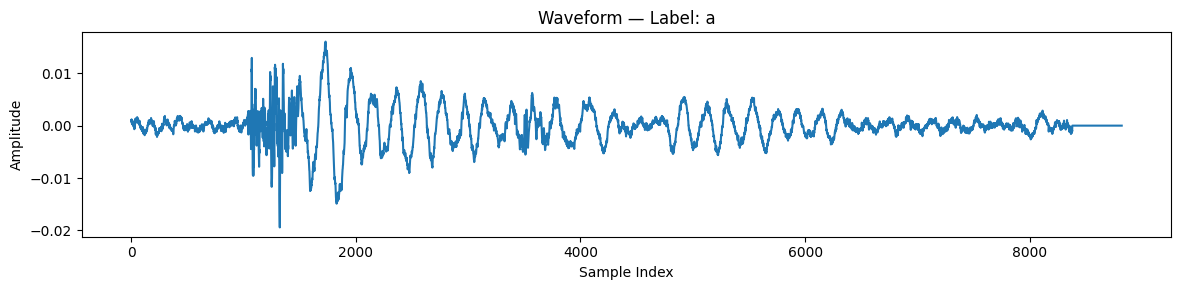

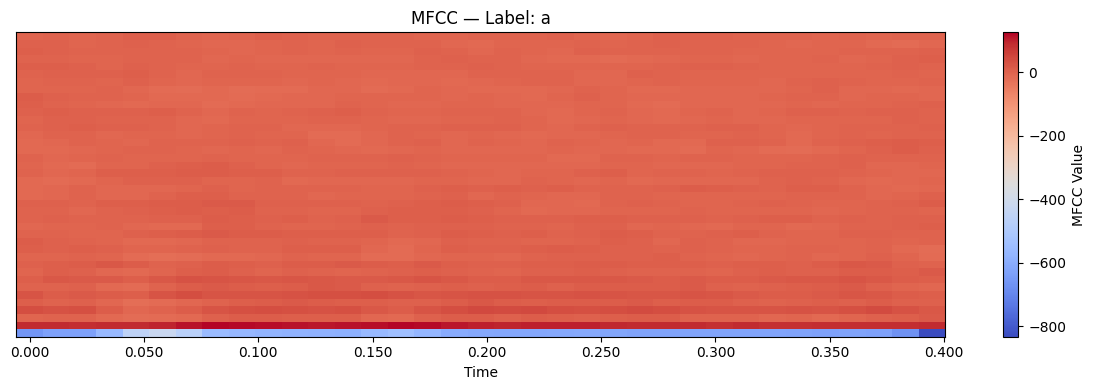

In [ ]:
y_audio, sr = librosa.load(sample_path, sr=SAMPLE_RATE, mono=True)

target_len = int(SAMPLE_RATE * DURATION)
if len(y_audio) < target_len:
    y_audio = np.pad(y_audio, (0, target_len - len(y_audio)))
else:
    y_audio = y_audio[:target_len]

plt.figure(figsize=(12, 3))
plt.plot(y_audio)
plt.title(f"Waveform — Label: {sample_label}")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

mfcc_vis = librosa.feature.mfcc(
    y=y_audio,
    sr=sr,
    n_mfcc=N_MFCC,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(
    mfcc_vis,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis='time'
)
plt.colorbar(img, label='MFCC Value')
plt.title(f"MFCC — Label: {sample_label}")
plt.tight_layout()
plt.show()

In [ ]:
def build_features(meta_df, split_name):
    X_list = []
    y_list = []

    print(f"Extracting {split_name} features from {len(meta_df)} files...")

    for _, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc=split_name):
        feat = extract_mfcc(row['filepath'])
        if feat is not None:
            X_list.append(feat)
            y_list.append(row['key'])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)

    print(f"{split_name} X shape: {X.shape}")
    print(f"{split_name} y shape: {y.shape}")

    return X, y

X_train, y_train_raw = build_features(train_meta, 'TRAIN')
X_valid, y_valid_raw = build_features(valid_meta, 'VALID')
X_test,  y_test_raw  = build_features(test_meta, 'TEST')

Extracting TRAIN features from 5120 files...


TRAIN: 100%|██████████| 5120/5120 [00:51<00:00, 99.83it/s] 


TRAIN X shape: (5120, 80)
TRAIN y shape: (5120,)
Extracting VALID features from 1280 files...


VALID: 100%|██████████| 1280/1280 [00:12<00:00, 101.89it/s]


VALID X shape: (1280, 80)
VALID y shape: (1280,)
Extracting TEST features from 1600 files...


TEST: 100%|██████████| 1600/1600 [00:14<00:00, 108.51it/s]

TEST X shape: (1600, 80)
TEST y shape: (1600,)


In [ ]:
le = LabelEncoder()

y_train = le.fit_transform(y_train_raw)
y_valid = le.transform(y_valid_raw)
y_test  = le.transform(y_test_raw)

print("Classes:", list(le.classes_))
print("Number of classes:", len(le.classes_))

Classes: [np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('space'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z')]
Number of classes: 27


In [ ]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_valid_sc = scaler.transform(X_valid)
X_test_sc  = scaler.transform(X_test)

print("Scaled shapes:")
print("Train:", X_train_sc.shape)
print("Valid:", X_valid_sc.shape)
print("Test :", X_test_sc.shape)

Scaled shapes:
Train: (5120, 80)
Valid: (1280, 80)
Test : (1600, 80)


In [ ]:
print("Training SVM baseline...")

svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42,
    decision_function_shape='ovr'
)

svm.fit(X_train_sc, y_train)

print("Training complete.")

Training SVM baseline...
Training complete.



===== VALID RESULTS =====
Accuracy: 95.23%

Classification Report:
              precision    recall  f1-score   support

           a       0.98      0.96      0.97        48
           b       0.94      0.98      0.96        48
           c       1.00      0.96      0.98        47
           d       0.96      0.98      0.97        48
           e       0.96      0.98      0.97        47
           f       0.96      0.94      0.95        48
           g       0.90      0.91      0.91        47
           h       0.95      0.89      0.92        47
           i       0.94      0.98      0.96        47
           j       0.81      0.94      0.87        47
           k       0.94      0.94      0.94        48
           l       1.00      0.96      0.98        47
           m       0.96      0.98      0.97        48
           n       0.98      0.98      0.98        47
           o       1.00      0.96      0.98        48
           p       1.00      0.94      0.97        47
           q 

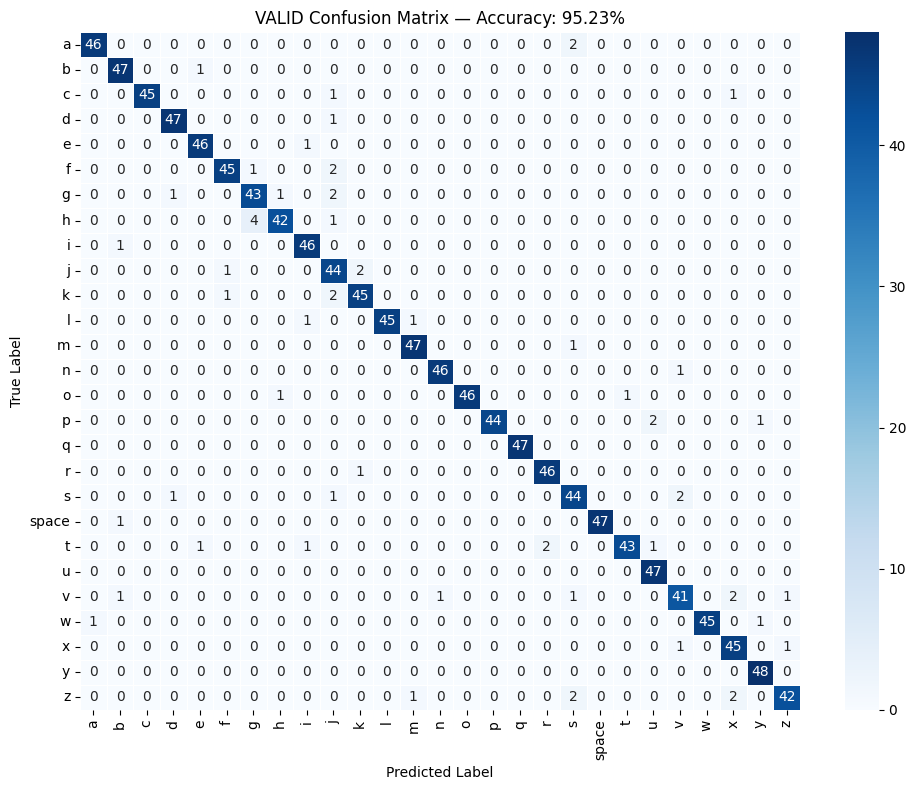


===== TEST RESULTS =====
Accuracy: 96.06%

Classification Report:
              precision    recall  f1-score   support

           a       0.92      0.98      0.95        59
           b       0.95      0.98      0.97        59
           c       1.00      0.98      0.99        59
           d       0.98      0.97      0.97        59
           e       0.98      0.97      0.97        59
           f       0.97      0.95      0.96        59
           g       0.95      0.92      0.93        59
           h       0.95      0.92      0.93        59
           i       1.00      0.98      0.99        60
           j       0.85      0.97      0.90        59
           k       0.95      0.97      0.96        59
           l       1.00      0.97      0.98        59
           m       0.97      1.00      0.98        59
           n       0.95      0.97      0.96        59
           o       0.98      0.98      0.98        59
           p       0.98      0.97      0.97        59
           q  

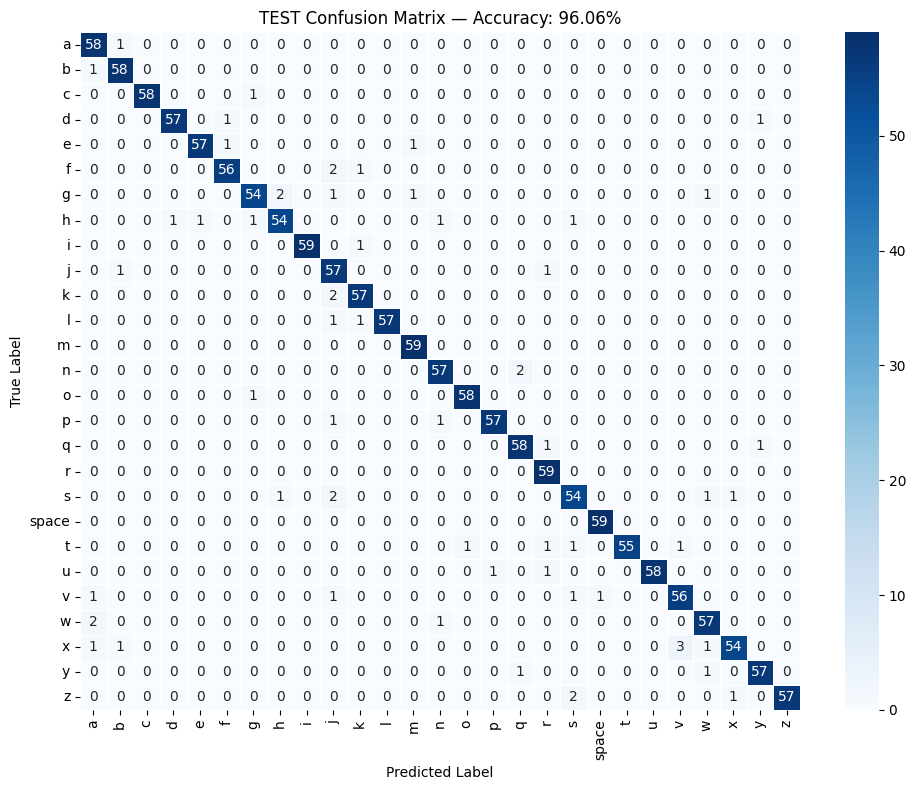

In [ ]:
def evaluate_model(model, X_data, y_true, split_name):
    y_pred = model.predict(X_data)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n===== {split_name} RESULTS =====")
    print(f"Accuracy: {acc * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        linewidths=0.5
    )
    plt.title(f'{split_name} Confusion Matrix — Accuracy: {acc*100:.2f}%')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return acc

valid_acc = evaluate_model(svm, X_valid_sc, y_valid, 'VALID')
test_acc  = evaluate_model(svm, X_test_sc,  y_test,  'TEST')

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/svm_keystroke_baseline_clean.pkl'

joblib.dump({
    'model': svm,
    'scaler': scaler,
    'label_encoder': le,
    'config': {
        'sample_rate': SAMPLE_RATE,
        'duration': DURATION,
        'n_mfcc': N_MFCC,
        'n_fft': N_FFT,
        'hop_length': HOP_LENGTH
    }
}, SAVE_PATH)

print("Model saved to:", SAVE_PATH)

Model saved to: /content/drive/MyDrive/svm_keystroke_baseline_clean.pkl
